# Metrics comparison between symbolic and numerical IK control

## Imports 

In [1]:
import ast
import numpy as np
import pandas as pd

# import matplotlib
# matplotlib.use("TkAgg")
import matplotlib.pyplot as plt
from metrics import l2_error, rodrigues_error

In [2]:
test = "line"  # line, circle, heart

filepath_sym = f"data/sym_{test}_data.csv"
filepath_num = f"data/num_{test}_data.csv"
filepath_qp = f"data/qp_{test}_data.csv"

df_sym = pd.read_csv(filepath_sym, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()
df_qp = pd.read_csv(filepath_qp, sep=",", header=0).copy()

display(df_sym.head(3))
df_sym.info()
df_num.info()

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,r_q2,r_q3,r_q4,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose
0,0.000000,0.787979,20.178421,18.729530,-85.170915,-10.227098,0.257685,34.014397,0.787979,-20.178421,-18.729530,-85.170915,10.227098,0.257685,-34.014397,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-4.182417706610764e-08, 1.5602190135780044e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.954404295853259e-07, 8.131026205131037e-0..."
1,0.008333,0.794420,20.138700,18.665771,-85.262440,-10.158288,0.334918,33.997738,0.794420,-20.138700,-18.665771,-85.262440,10.158288,0.334918,-33.997738,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-7.00209806803187e-09, 1.5208070553644395e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.602603890934702e-07, 8.52577660759851e-07..."
2,0.016667,0.800686,20.099058,18.601837,-85.353671,-10.089390,0.412070,33.980881,0.800686,-20.099058,-18.601837,-85.353671,10.089390,0.412070,-33.980881,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-4.119230045951383e-08, 1.5204824949266857e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.940885273840294e-07, 8.529696107103227e-0..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         480 non-null    float64
 1   l_q0         480 non-null    float64
 2   l_q1         480 non-null    float64
 3   l_q2         480 non-null    float64
 4   l_q3         480 non-null    float64
 5   l_q4         480 non-null    float64
 6   l_q5         480 non-null    float64
 7   l_q6         480 non-null    float64
 8   r_q0         480 non-null    float64
 9   r_q1         480 non-null    float64
 10  r_q2         480 non-null    float64
 11  r_q3         480 non-null    float64
 12  r_q4         480 non-null    float64
 13  r_q5         480 non-null    float64
 14  r_q6         480 non-null    float64
 15  l_pose       480 non-null    object 
 16  l_real_pose  480 non-null    object 
 17  r_pose       480 non-null    object 
 18  r_real_pose  480 non-null    object 
dtypes: float

In [3]:
def parse_pose_matrix(matrix_str):
    """Convert a string of a matrix into a NumPy array."""
    return np.array(ast.literal_eval(matrix_str))

In [4]:
l_pos_errs = []
l_rot_errs = []
r_pos_errs = []
r_rot_errs = []

for _, row in df_sym.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_sym["l_pos_err"] = l_pos_errs
df_sym["l_rot_err"] = l_rot_errs

df_sym["r_pos_err"] = r_pos_errs
df_sym["r_rot_err"] = r_rot_errs

display(df_sym.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,r_pos_err,r_rot_err
0,0.000000,0.787979,20.178421,18.729530,-85.170915,-10.227098,0.257685,34.014397,0.787979,-20.178421,...,0.257685,-34.014397,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-4.182417706610764e-08, 1.5602190135780044e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.954404295853259e-07, 8.131026205131037e-0...",2.599180e-07,0.000002,3.058788e-07,0.000001
1,0.008333,0.794420,20.138700,18.665771,-85.262440,-10.158288,0.334918,33.997738,0.794420,-20.138700,...,0.334918,-33.997738,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-7.00209806803187e-09, 1.5208070553644395e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.602603890934702e-07, 8.52577660759851e-07...",2.380834e-07,0.000002,2.948468e-07,0.000002
2,0.016667,0.800686,20.099058,18.601837,-85.353671,-10.089390,0.412070,33.980881,0.800686,-20.099058,...,0.412070,-33.980881,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-4.119230045951383e-08, 1.5204824949266857e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-9.940885273840294e-07, 8.529696107103227e-0...",2.438966e-07,0.000002,3.057947e-07,0.000002


In [5]:
l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_num.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_num["l_pos_err"] = l_pos_errs
df_num["l_rot_err"] = l_rot_errs

df_num["r_pos_err"] = r_pos_errs
df_num["r_rot_err"] = r_rot_errs

l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_qp.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_qp["l_pos_err"] = l_pos_errs
df_qp["l_rot_err"] = l_rot_errs

df_qp["r_pos_err"] = r_pos_errs
df_qp["r_rot_err"] = r_rot_errs

display(df_num.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,r_pos_err,r_rot_err
0,0.000000,-1.955021,13.721056,25.526418,-85.170895,-17.063143,2.049288,26.643318,-1.952270,-13.726654,...,2.047254,-26.649843,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-7.881707120294124e-09, 1.763354402175384e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[1.620034756344424e-08, 1.1792983414014841e-0...",5.898167e-09,2.058382e-08,7.294283e-09,2.200233e-08
1,0.008333,-1.949496,13.661321,25.476751,-85.259489,-17.007028,2.118583,26.615203,-1.946646,-13.666198,...,2.117428,-26.621400,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-8.991227173904548e-08, 1.937733592045776e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-2.3135903737259156e-07, -3.7881433138969077...",1.131782e-05,2.162023e-07,3.083815e-05,4.549127e-07
2,0.016667,-1.943807,13.599779,25.425463,-85.350734,-16.949126,2.189999,26.586061,-1.940963,-13.604664,...,2.188851,-26.592252,"[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-4.484656562775413e-08, 1.3058114269425426e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.4], [0....","[[-1.452987226091551e-07, -2.697817770359596e-...",6.858096e-06,1.446641e-07,1.868328e-05,3.179946e-07


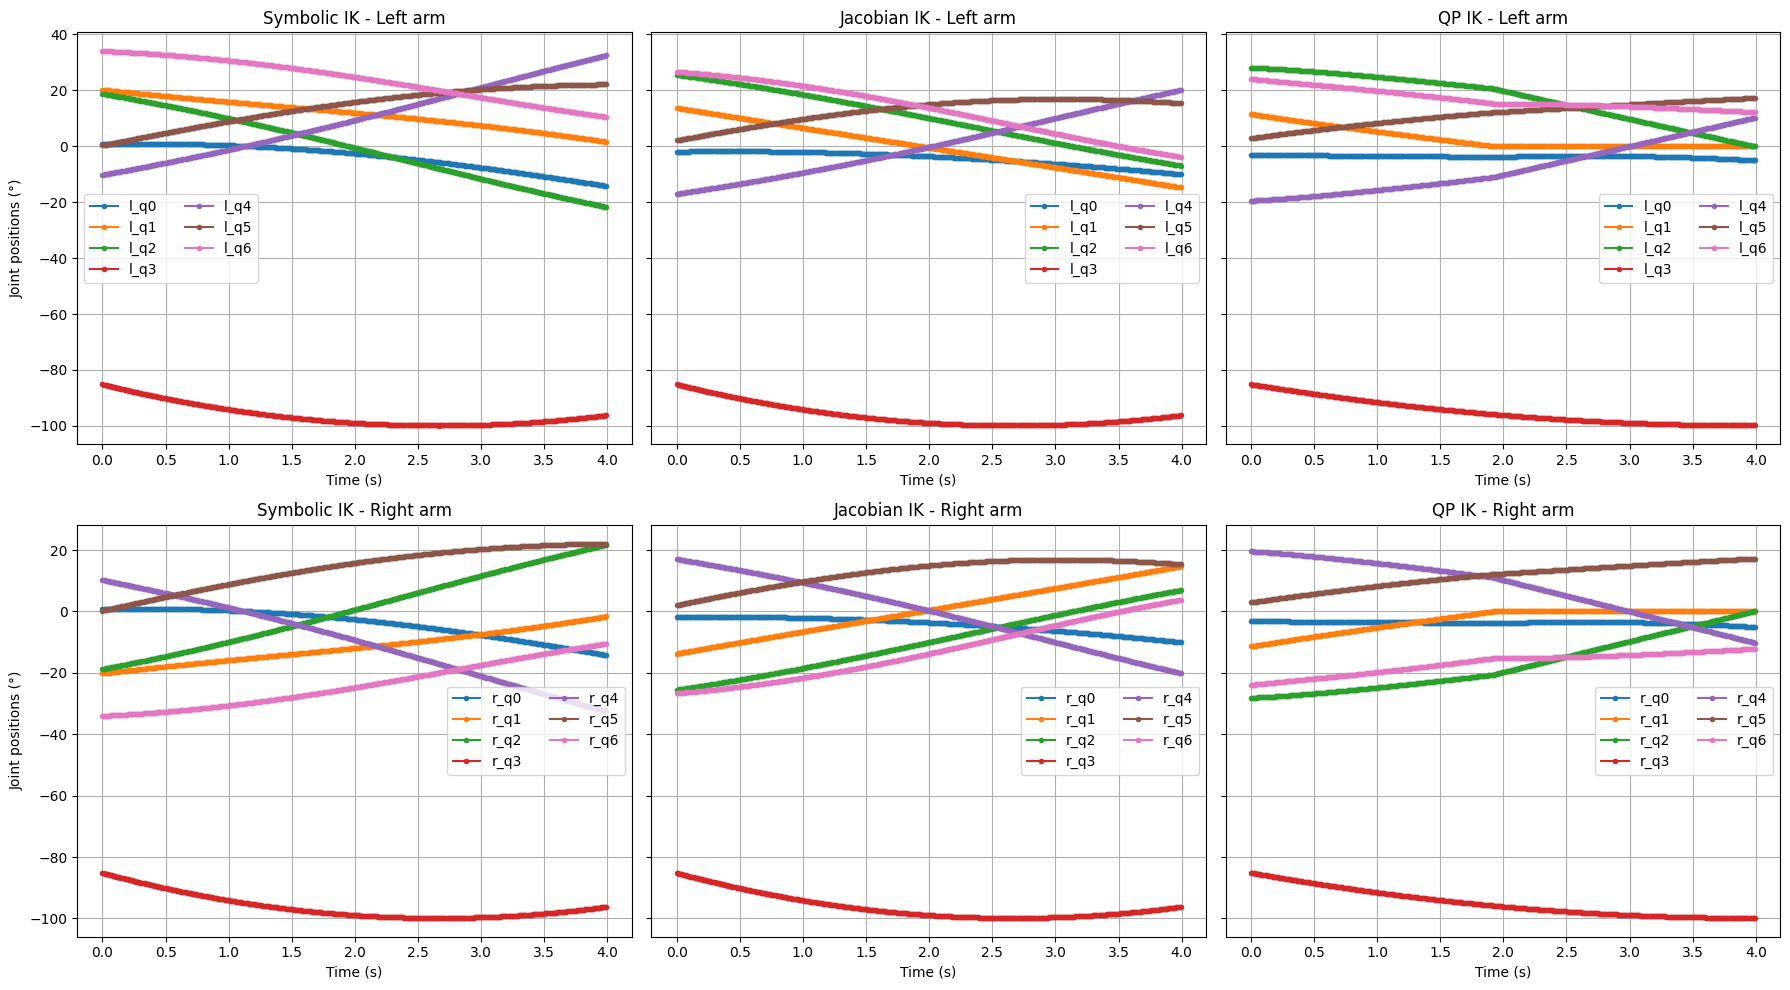

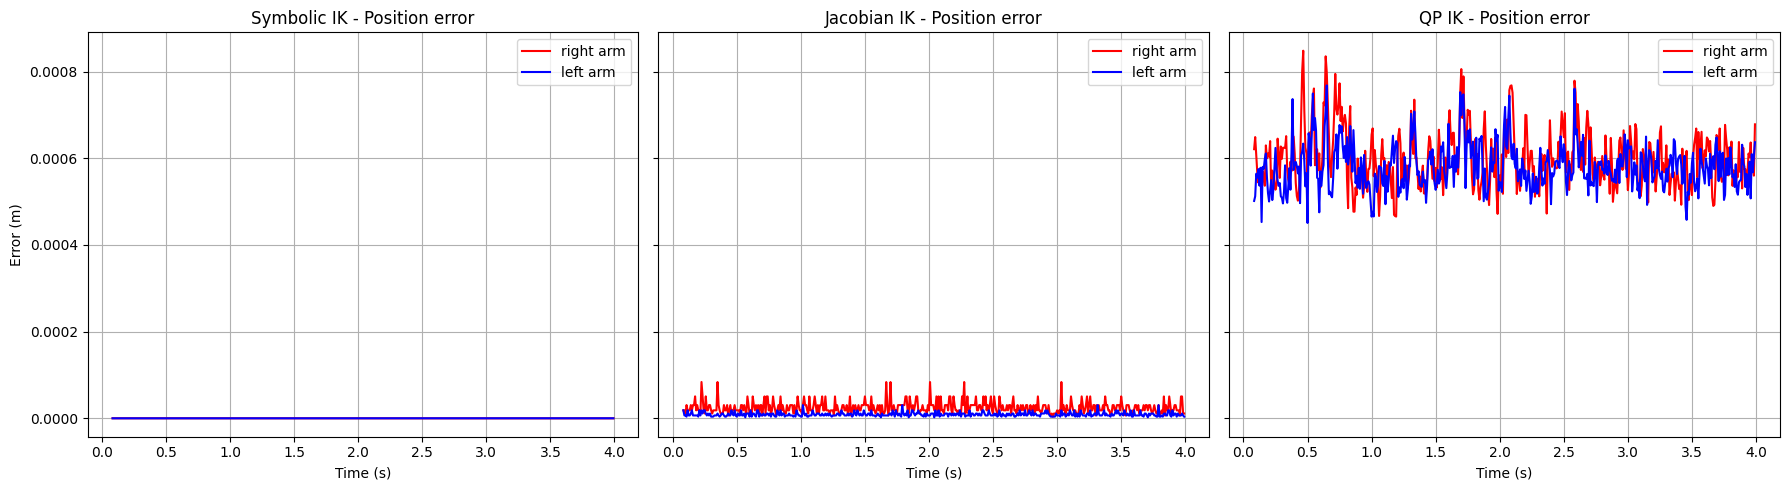

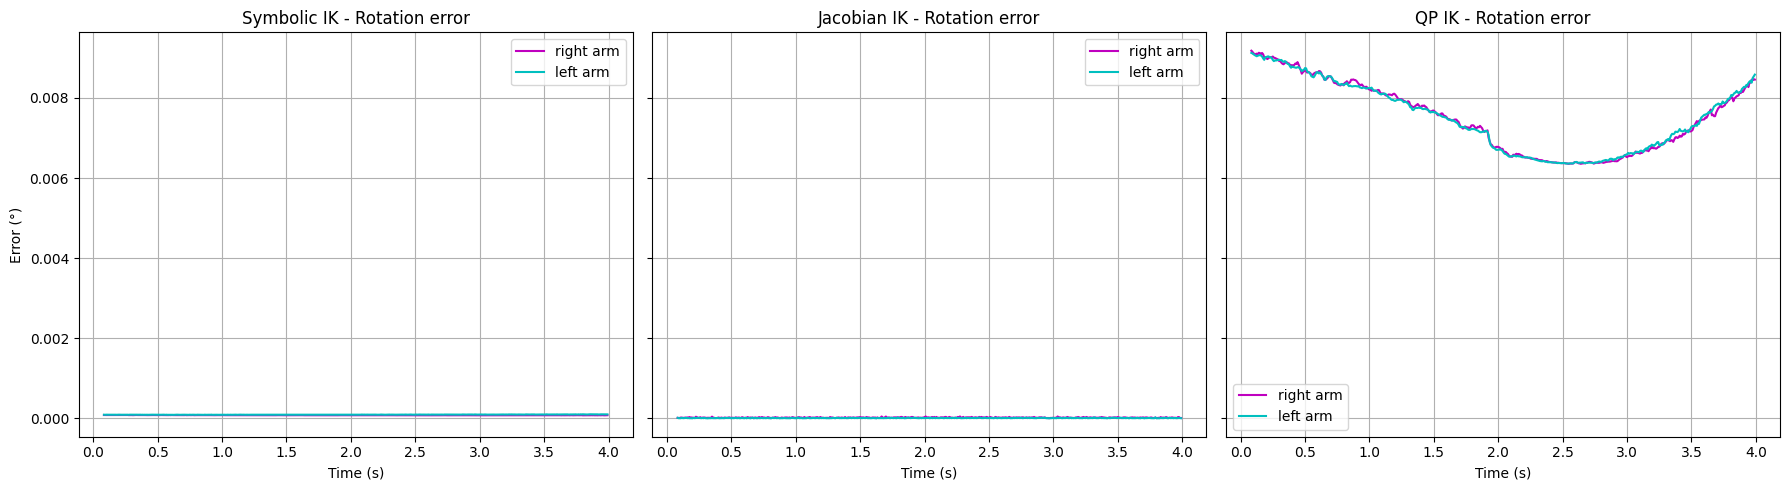

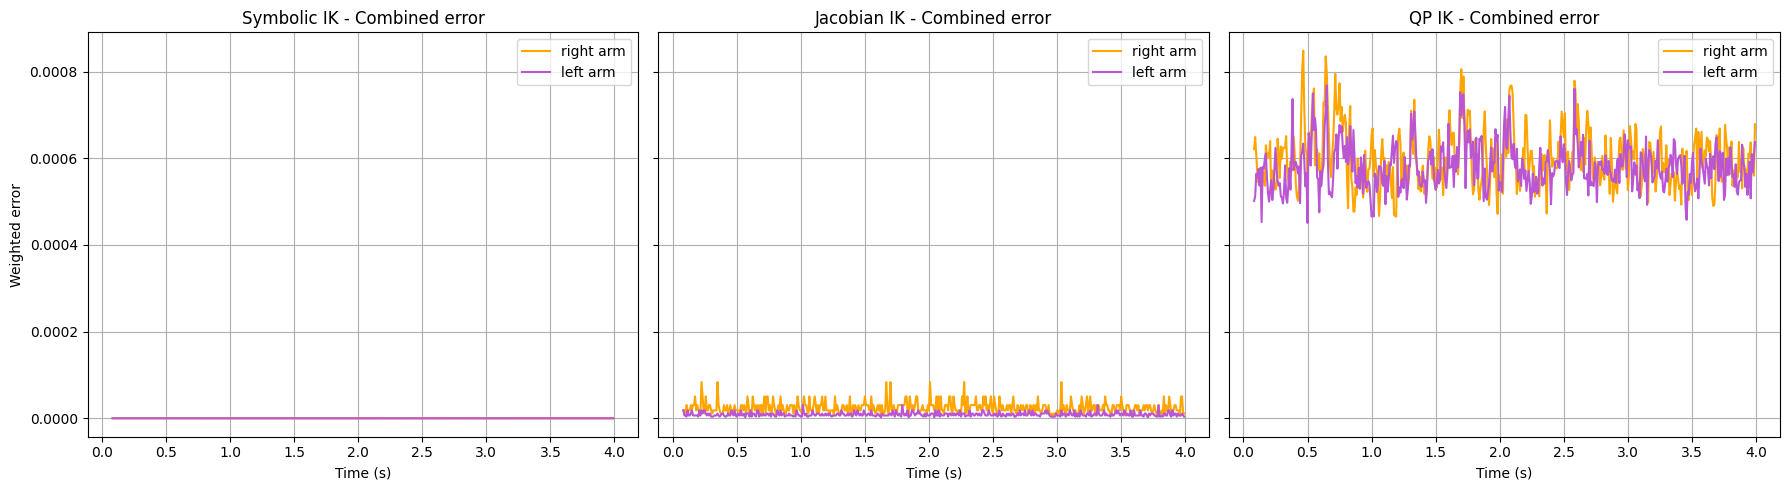

In [6]:
dfs = [(df_sym, "Symbolic IK"), (df_num, "Jacobian IK"), (df_qp, "QP IK")]
l_cols = [f"l_q{i}" for i in range(7)]
r_cols = [f"r_q{i}" for i in range(7)]

time_slice = slice(10, None)
lambda_theta = 1e-6 / np.deg2rad(1) ** 2

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey="row")
for idx, (df, title) in enumerate(dfs):
    for col in l_cols:
        axes[0, idx].plot(df["time"], df[col], marker=".")
    axes[0, idx].set_title(f"{title} - Left arm")
    axes[0, idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[0, idx].set_ylabel("Joint positions (°)")
    axes[0, idx].grid(True)
    axes[0, idx].legend(l_cols, ncol=2)

    for col in r_cols:
        axes[1, idx].plot(df["time"], df[col], marker=".")
    axes[1, idx].set_title(f"{title} - Right arm")
    axes[1, idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[1, idx].set_ylabel("Joint positions (°)")
    axes[1, idx].grid(True)
    axes[1, idx].legend(r_cols, ncol=2)

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df, title) in enumerate(dfs):
    axes[idx].plot(df["time"][time_slice], df["r_pos_err"][time_slice], label="right arm", color="red")
    axes[idx].plot(df["time"][time_slice], df["l_pos_err"][time_slice], label="left arm", color="blue")
    axes[idx].set_title(f"{title} - Position error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Error (m)")
    axes[idx].legend()
    axes[idx].grid(True)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df, title) in enumerate(dfs):
    axes[idx].plot(df["time"][time_slice], np.rad2deg(df["r_rot_err"][time_slice]), label="right arm", color="m")
    axes[idx].plot(df["time"][time_slice], np.rad2deg(df["l_rot_err"][time_slice]), label="left arm", color="c")
    axes[idx].set_title(f"{title} - Rotation error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Error (°)")
    axes[idx].legend()
    axes[idx].grid(True)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df, title) in enumerate(dfs):
    comb_l = np.sqrt(df["l_pos_err"] ** 2 + (lambda_theta * df["l_rot_err"] ** 2))
    comb_r = np.sqrt(df["r_pos_err"] ** 2 + (lambda_theta * df["r_rot_err"] ** 2))
    axes[idx].plot(df["time"][time_slice], comb_r[time_slice], label="right arm", color="orange")
    axes[idx].plot(df["time"][time_slice], comb_l[time_slice], label="left arm", color="mediumorchid")
    axes[idx].set_title(f"{title} - Combined error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Weighted error")
    axes[idx].legend()
    axes[idx].grid(True)
fig.tight_layout()
plt.show()

## Parameters influence 

### Proportionnal corrector $K_p$

In [7]:
method = "num"

mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for kp in [
    "0010",
    "0025",
    "0050",
    "0075",
    "0100",
    "0125",
    "0150",
    "0175",
    "0200",
    "0300",
    "0400",
    "0500",
    "0600",
    "0750",
    "1000",
]:
    filepath_num = f"data/{method}_circle_data_kp{kp}.csv"
    df_num2 = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num2.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())

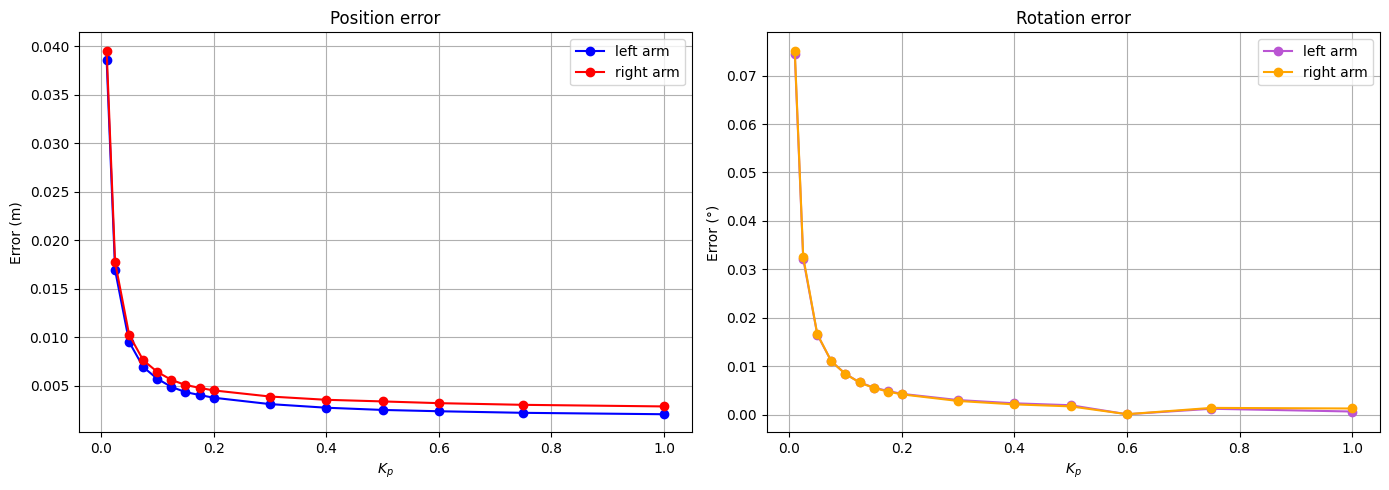

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Kp = [0.01, 0.025, 0.050, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.3, 0.4, 0.5, 0.6, 0.75, 1.0]

axes[0].plot(Kp, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(Kp, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("$K_p$")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(Kp, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(Kp, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("$K_p$")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Integration step `ik_step` 

In [9]:
mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for step in ["00010", "00020", "00030", "00040", "00050"]:
    filepath_num = f"data/num_circle_data_ikstep{step}.csv"
    df_num2 = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num2.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())

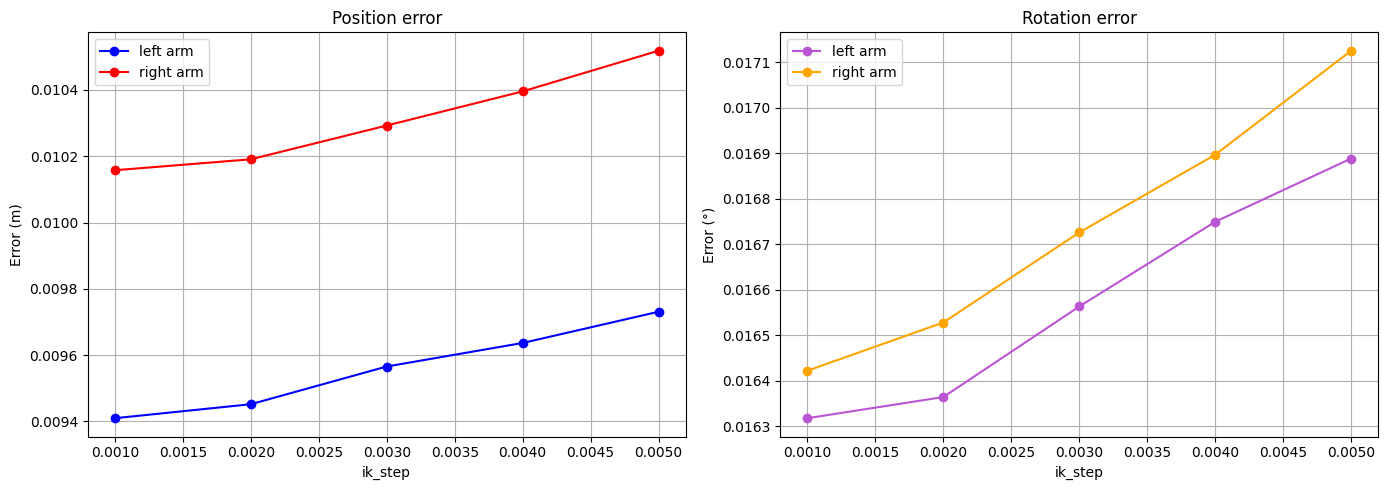

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

step = [0.001, 0.002, 0.003, 0.004, 0.005]

axes[0].plot(step, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(step, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("ik_step")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(step, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(step, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("ik_step")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Damping factor $\lambda$

In [11]:
mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for step in ["075e10", "075e9", "075e8", "075e7", "075e6", "075e5", "075e4", "075e3", "075e2", "075e1"]:
    filepath_num = f"data/num_circle_data_l{step}.csv"
    df_num2 = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num2.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())

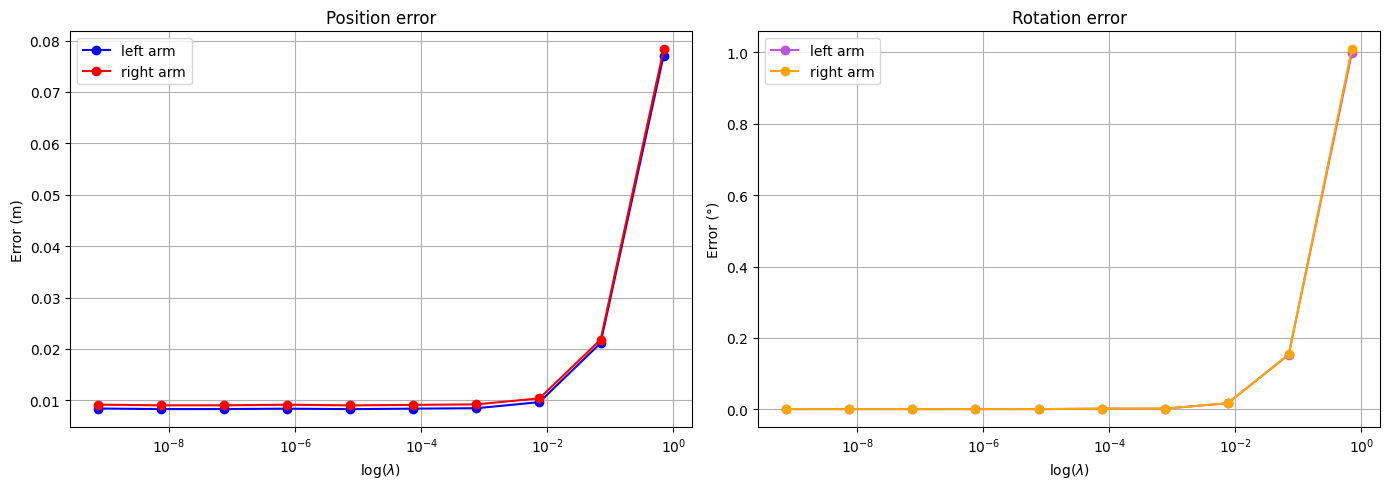

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_lambda = [7.5e-10, 7.5e-9, 7.5e-8, 7.5e-7, 7.5e-6, 7.5e-5, 7.5e-4, 7.5e-3, 7e-2, 7e-1]

axes[0].plot(_lambda, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(_lambda, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("$\\log(\\lambda)$")
axes[0].set_xscale("log")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(_lambda, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(_lambda, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("$\\log(\\lambda)$")
axes[1].set_xscale("log")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3D Trajectories

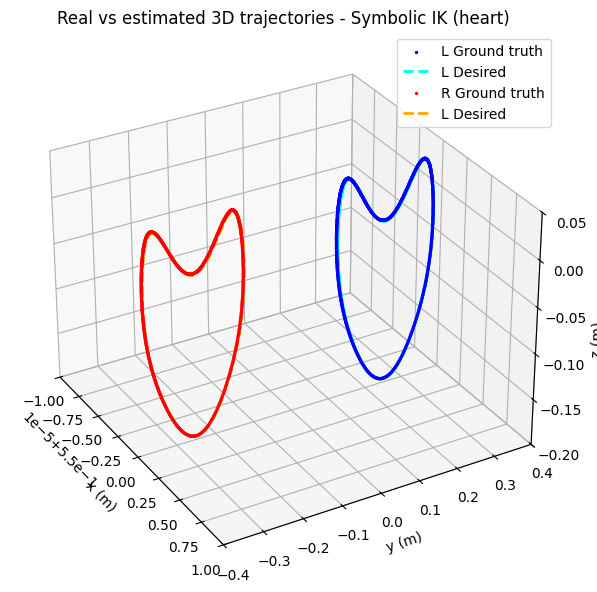

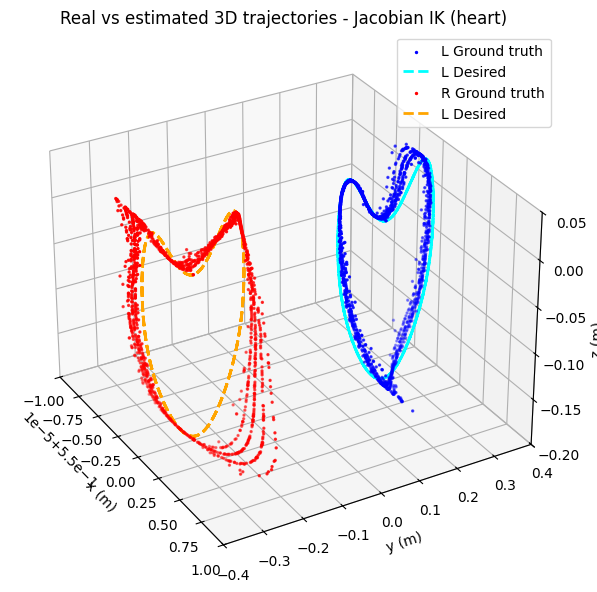

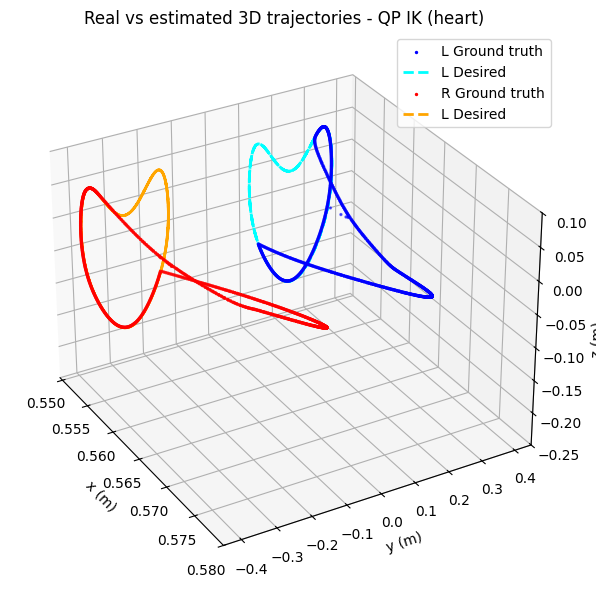

In [13]:
from mpl_toolkits.mplot3d import Axes3D


test = "heart"  # line, circle, heart

filepath_sym = f"data/sym_{test}_data.csv"
filepath_num = f"data/num_{test}_data.csv"
filepath_qp = f"data/qp_{test}_data.csv"

df_sym = pd.read_csv(filepath_sym, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()
df_qp = pd.read_csv(filepath_qp, sep=",", header=0).copy()


if test == "line":
    elev = 30
    azim = -30
    xlim = [0.39999, 0.40001]
    ylim = [-0.5, 0.5]
    zlim = [-(2e-1 - 3e-7), -(2e-1 + 3e-7)]
elif test == "heart":
    elev = 30
    azim = -30
    xlim = [0.54999, 0.55001]
    ylim = [-0.4, 0.4]
    zlim = [-0.2, 0.05]
elif test == "circle":
    elev = 30
    azim = -30
    xlim = [0.3999, 0.4001]
    ylim = [-0.6, 0.6]
    zlim = [-0.35, -0.06]


def extract_trajectory(df, col_name):
    xs, ys, zs = [], [], []
    for pose_str in df[col_name]:
        pose = parse_pose_matrix(pose_str)
        x, y, z = pose[:3, 3]
        xs.append(x)
        ys.append(y)
        zs.append(z)
    return xs, ys, zs


for name, df in zip(["Symbolic IK", "Jacobian IK", "QP IK"], [df_sym, df_num, df_qp]):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.view_init(elev=elev, azim=azim)

    l_x_gth, l_y_gth, l_z_gth = extract_trajectory(df, "l_real_pose")
    l_x_des, l_y_des, l_z_des = extract_trajectory(df, "l_pose")

    r_x_gth, r_y_gth, r_z_gth = extract_trajectory(df, "r_real_pose")
    r_x_des, r_y_des, r_z_des = extract_trajectory(df, "r_pose")

    ax.scatter(l_x_gth, l_y_gth, l_z_gth, label="L Ground truth", color="blue", s=2)
    ax.plot(l_x_des, l_y_des, l_z_des, label="L Desired", linestyle="--", color="cyan", linewidth=2)

    ax.scatter(r_x_gth, r_y_gth, r_z_gth, label="R Ground truth", color="red", s=2)
    ax.plot(r_x_des, r_y_des, r_z_des, label="L Desired", linestyle="--", color="orange", linewidth=2)

    ax.set_title(f"Real vs estimated 3D trajectories - {name} ({test})")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_zlabel("z (m)")
    if name == "QP IK":
        if test == "line":
            ax.set_xlim(0.3995, 0.4005)
            ax.set_ylim(-0.55, 0.55)
            ax.set_zlim(-0.205, -0.195)
        elif test == "heart":
            ax.set_xlim(0.5495, 0.58)
            ax.set_ylim(-0.45, 0.45)
            ax.set_zlim(-0.25, 0.1)
        elif test == "circle":
            ax.set_xlim(0.385, 0.415)
            ax.set_ylim(-0.65, 0.65)
            ax.set_zlim(-0.4, -0.05)
    else:
        ax.set_xlim(xlim[0], xlim[1])
        ax.set_ylim(ylim[0], ylim[1])
        ax.set_zlim(zlim[0], zlim[1])

    ax.legend()
    plt.tight_layout()
    ax.grid(True)
    plt.show()